In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np

import matplotlib.pyplot as plt

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

In [4]:
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Binary offset
delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
print(f'Binary offset: {delta1}')

# Correcting binary lens attributes
binary_lens_attributes[:, :2] -= delta1

# Map parameters
pixels = 2000
delta = 0.01

ang_width, thickness, (y_plus, y_minus), cusp_points = IRSC.IRSCaustics.ang_width_thickness_calculator(binary_lens_attributes)
num_r, num_theta = IRSC.IRSCaustics.num_ray_calculator(pixels, ang_width, delta, y_plus, y_minus)

Binary offset: [0.00048732 0.        ]


In [5]:
num_r = 20000
num_theta = 5000

print(ang_width)
print(num_r, num_theta)
print(thickness, y_plus, y_minus)
print(f'Total number of rays: {num_r * num_theta:.4e}')

0.07680319680319682
20000 5000
0.059738867403980045 1.030315425782361 -0.970576558378381
Total number of rays: 1.0000e+08


In [6]:
thetas = np.linspace(0, 2*np.pi - (2*np.pi/num_theta), num_theta).reshape(1, -1)
print(thetas.shape)

(1, 5000)


In [7]:
theta_group = np.array_split(thetas[0], 6)

In [8]:
for group in theta_group:
    print(group.shape[0])

print(np.sum([group.shape[0] for group in theta_group]))

834
834
833
833
833
833
5000


In [12]:
binary_series_local = IRSC.caustic_reader('../Unity/Simulations/Binary_Collection/binary_1e-03_0.8_series_local.pkl')
binary_parallel_local = IRSC.caustic_reader('../Unity/Simulations/Binary_Collection/binary_1e-03_0.8_parallel_local.pkl')

Plotting magnification map: 0.015 seconds
Plotting magnification map: 0.039 seconds


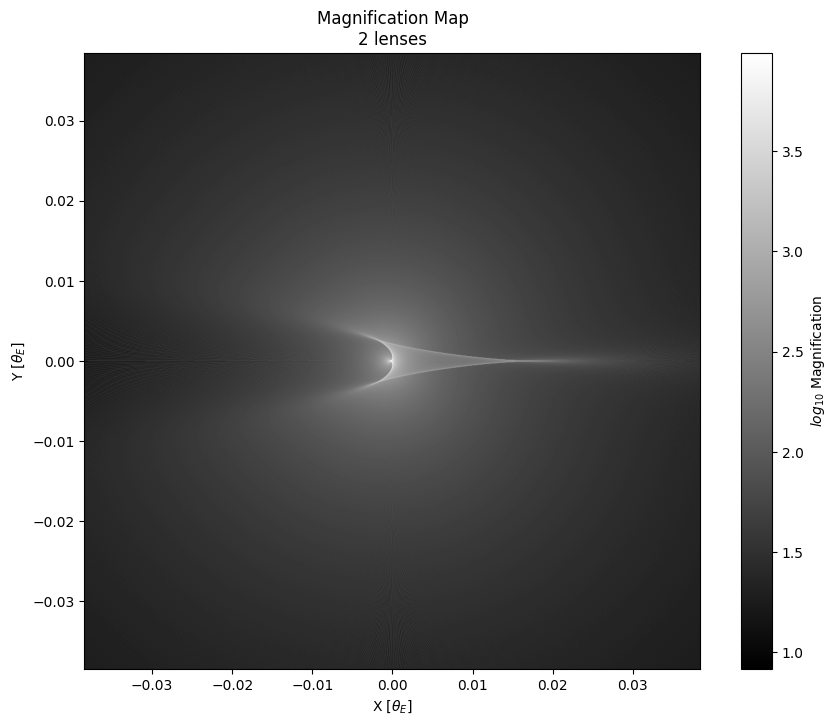

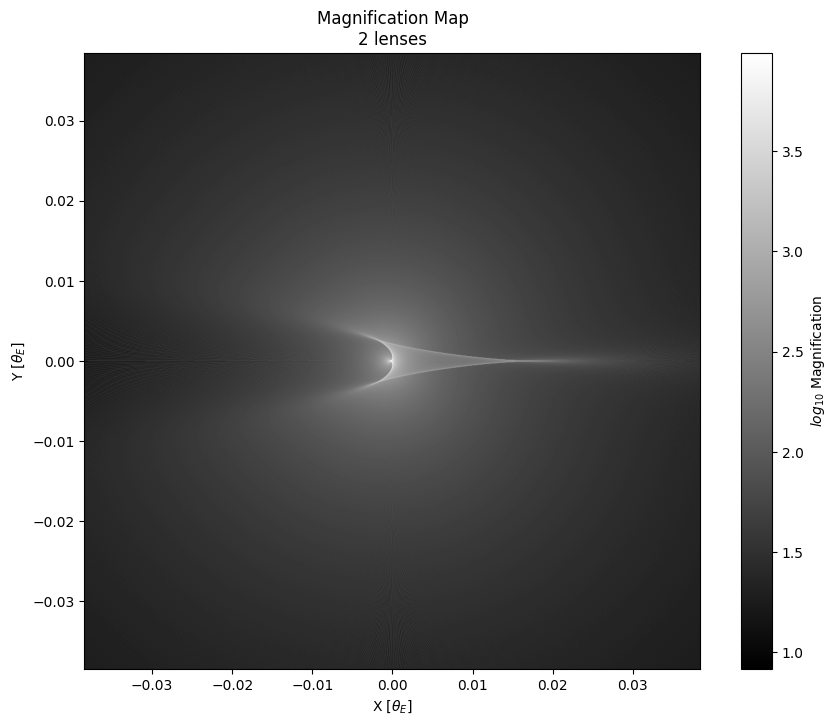

In [13]:
binary_series_local.plot()
binary_parallel_local.plot()

plt.show()

In [15]:
print((binary_series_local.magnifications == binary_parallel_local.magnifications).all())

True


In [16]:
binary_series_unity = IRSC.caustic_reader('../Unity/Simulations/Binary_Collection/binary_1e-03_0.8_series_unity.pkl')
binary_parallel_unity = IRSC.caustic_reader('../Unity/Simulations/Binary_Collection/binary_1e-03_0.8_parallel_unity.pkl')

Plotting magnification map: 0.014 seconds
Plotting magnification map: 0.015 seconds


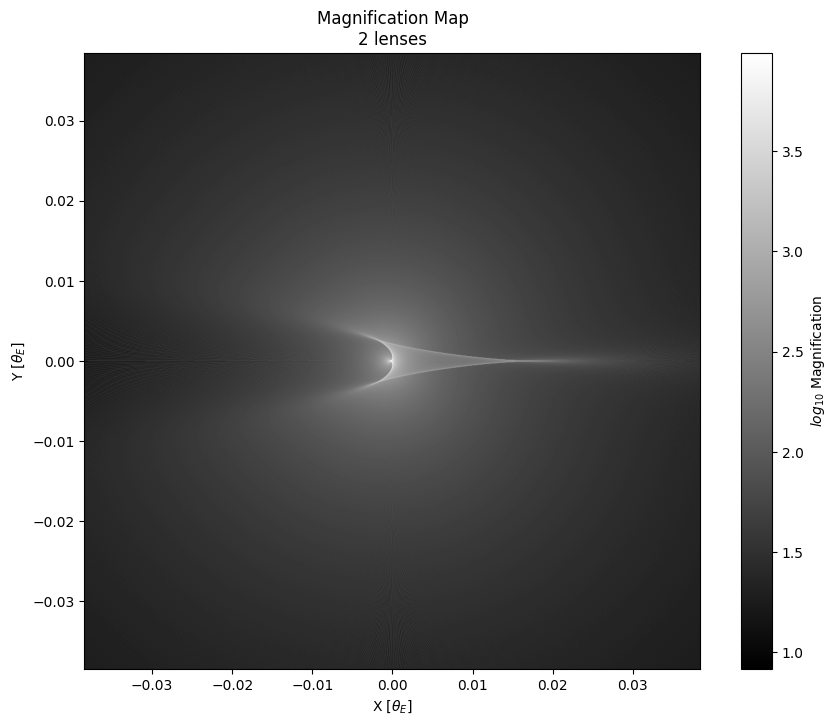

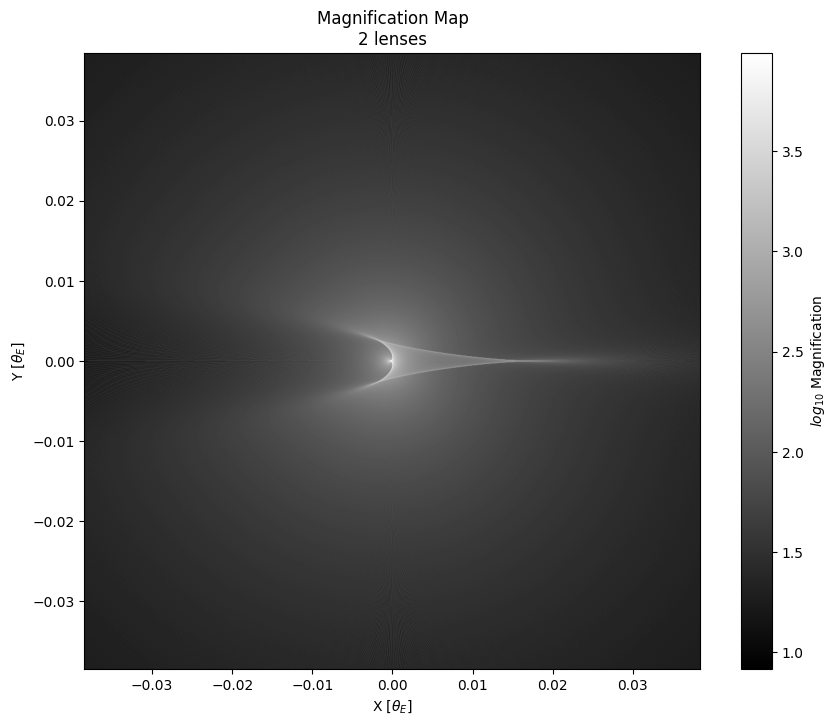

In [17]:
binary_series_unity.plot()
binary_parallel_unity.plot()

plt.show()

In [18]:
print((binary_series_unity.magnifications == binary_parallel_unity.magnifications).all())

True


In [19]:
print((binary_series_local.magnifications == binary_parallel_unity.magnifications).all())

True
